In [1]:
import re
import pandas as pd

In [2]:
f=open('WhatsApp Chat with Cs-1  Unofficial.txt','r',encoding='utf-8')

In [3]:
data=f.read()

In [7]:
print(data)

07/09/22, 10:02 am - Messages and calls are end-to-end encrypted. No one outside of this chat, not even WhatsApp, can read or listen to them. Tap to learn more.
07/09/22, 10:00 am - Arun Akg created group "CS-1 unofficial  "
07/09/22, 10:02 am - Archas Akg added you
07/09/22, 10:02 am - Deepak Khandelwal Akg added +91 70681 17946
07/09/22, 10:02 am - Deepak Khandelwal Akg added +91 81268 10072
07/09/22, 10:02 am - Alan Akg added +91 70786 55644
07/09/22, 10:02 am - Himanshi Cs Akg: Ek link Bana ke send krdo...sb khud add ho jaenge
07/09/22, 10:03 am - Himanshi Cs Akg: Or vo circulate krdo
07/09/22, 10:03 am - +91 73557 10090 joined using this group's invite link
07/09/22, 10:03 am - +91 6388 087 440 joined using this group's invite link
07/09/22, 10:03 am - Archas Akg added Khushi Khurana Akg, +91 75058 47365, +91 88825 76298 and +91 93692 03013
07/09/22, 10:03 am - You're now an admin
07/09/22, 10:03 am - +91 87003 76567 joined using this group's invite link
07/09/22, 10:03 am - +91 8

In [11]:
pattern='\d{1,2}/\d{1,2}/\d{2,4},\s\d{1,2}:\d{2}\s\w{2}\s-\s'

In [13]:
messages=re.split(pattern,data)[1:]
messages

['Messages and calls are end-to-end encrypted. No one outside of this chat, not even WhatsApp, can read or listen to them. Tap to learn more.\n',
 'Arun Akg created group "CS-1 unofficial  "\n',
 'Archas Akg added you\n',
 'Deepak Khandelwal Akg added +91 70681 17946\n',
 'Deepak Khandelwal Akg added +91 81268 10072\n',
 'Alan Akg added +91 70786 55644\n',
 'Himanshi Cs Akg: Ek link Bana ke send krdo...sb khud add ho jaenge\n',
 'Himanshi Cs Akg: Or vo circulate krdo\n',
 "+91 73557 10090 joined using this group's invite link\n",
 "+91 6388 087 440 joined using this group's invite link\n",
 'Archas Akg added Khushi Khurana Akg, +91 75058 47365, +91 88825 76298 and +91 93692 03013\n',
 "You're now an admin\n",
 "+91 87003 76567 joined using this group's invite link\n",
 "+91 82736 28839 joined using this group's invite link\n",
 'You added Bhavishya Akg\n',
 'Alan Akg added +91 90268 38893\n',
 "+91 87911 49657 joined using this group's invite link\n",
 'Alan Akg added +91 98716 13713\n

In [44]:
dates=re.findall(pattern,data)
for i in range(len(dates)):
    dates[i]=dates[i].replace(' - ','').replace(',','')
dates

['07/09/22 10:02 am',
 '07/09/22 10:00 am',
 '07/09/22 10:02 am',
 '07/09/22 10:02 am',
 '07/09/22 10:02 am',
 '07/09/22 10:02 am',
 '07/09/22 10:02 am',
 '07/09/22 10:03 am',
 '07/09/22 10:03 am',
 '07/09/22 10:03 am',
 '07/09/22 10:03 am',
 '07/09/22 10:03 am',
 '07/09/22 10:03 am',
 '07/09/22 10:03 am',
 '07/09/22 10:03 am',
 '07/09/22 10:04 am',
 '07/09/22 10:04 am',
 '07/09/22 10:04 am',
 '07/09/22 10:04 am',
 '07/09/22 10:04 am',
 '07/09/22 10:04 am',
 '07/09/22 10:04 am',
 '07/09/22 10:04 am',
 '07/09/22 10:06 am',
 '07/09/22 10:06 am',
 '07/09/22 10:06 am',
 '07/09/22 10:06 am',
 '07/09/22 10:07 am',
 '07/09/22 10:07 am',
 '07/09/22 10:07 am',
 '07/09/22 10:07 am',
 '07/09/22 10:07 am',
 '07/09/22 10:08 am',
 '07/09/22 10:08 am',
 '07/09/22 10:08 am',
 '07/09/22 10:08 am',
 '07/09/22 10:08 am',
 '07/09/22 10:09 am',
 '07/09/22 10:09 am',
 '07/09/22 10:09 am',
 '07/09/22 10:09 am',
 '07/09/22 10:10 am',
 '07/09/22 10:10 am',
 '07/09/22 10:10 am',
 '07/09/22 10:10 am',
 '07/09/22

In [56]:
df=pd.DataFrame({'user_message':messages,'date':dates})
df['date']=pd.to_datetime(df['date'])
df.head()

,user_message,date
0,Messages and calls are end-to-end encrypted. N...,2022-07-09 10:02:00
1,"Arun Akg created group ""CS-1 unofficial ""\n",2022-07-09 10:00:00
2,Archas Akg added you\n,2022-07-09 10:02:00
3,Deepak Khandelwal Akg added +91 70681 17946\n,2022-07-09 10:02:00
4,Deepak Khandelwal Akg added +91 81268 10072\n,2022-07-09 10:02:00


In [58]:
users=[]
message=[]
for m in df['user_message']:
    entry=re.split('([\w\W]+?):\s',m)
    if entry[1:]:
        users.append(entry[1])
        message.append(entry[2])
    else:
        users.append('group_notification')
        message.append(entry[0])
df['user']=users
df['message']=message
df.drop(columns='user_message',inplace=True)
df

,date,user,message
0,2022-07-09 10:02:00,group_notification,Messages and calls are end-to-end encrypted. N...
1,2022-07-09 10:00:00,group_notification,"Arun Akg created group ""CS-1 unofficial ""\n"
2,2022-07-09 10:02:00,group_notification,Archas Akg added you\n
3,2022-07-09 10:02:00,group_notification,Deepak Khandelwal Akg added +91 70681 17946\n
4,2022-07-09 10:02:00,group_notification,Deepak Khandelwal Akg added +91 81268 10072\n
5,2022-07-09 10:02:00,group_notification,Alan Akg added +91 70786 55644\n
6,2022-07-09 10:02:00,Himanshi Cs Akg,Ek link Bana ke send krdo...sb khud add ho jae...
7,2022-07-09 10:03:00,Himanshi Cs Akg,Or vo circulate krdo\n
8,2022-07-09 10:03:00,group_notification,+91 73557 10090 joined using this group's invi...
9,2022-07-09 10:03:00,group_notification,+91 6388 087 440 joined using this group's inv...


In [61]:
df['year']=df['date'].dt.year
df['month']=df['date'].dt.month_name()
df['day']=df['date'].dt.day
df['hour']=df['date'].dt.hour
df['minute']=df['date'].dt.minute 

In [62]:
df

,date,user,message,year,month,day,hour,minute
0,2022-07-09 10:02:00,group_notification,Messages and calls are end-to-end encrypted. N...,2022,July,9,10,2
1,2022-07-09 10:00:00,group_notification,"Arun Akg created group ""CS-1 unofficial ""\n",2022,July,9,10,0
2,2022-07-09 10:02:00,group_notification,Archas Akg added you\n,2022,July,9,10,2
3,2022-07-09 10:02:00,group_notification,Deepak Khandelwal Akg added +91 70681 17946\n,2022,July,9,10,2
4,2022-07-09 10:02:00,group_notification,Deepak Khandelwal Akg added +91 81268 10072\n,2022,July,9,10,2
5,2022-07-09 10:02:00,group_notification,Alan Akg added +91 70786 55644\n,2022,July,9,10,2
6,2022-07-09 10:02:00,Himanshi Cs Akg,Ek link Bana ke send krdo...sb khud add ho jae...,2022,July,9,10,2
7,2022-07-09 10:03:00,Himanshi Cs Akg,Or vo circulate krdo\n,2022,July,9,10,3
8,2022-07-09 10:03:00,group_notification,+91 73557 10090 joined using this group's invi...,2022,July,9,10,3
9,2022-07-09 10:03:00,group_notification,+91 6388 087 440 joined using this group's inv...,2022,July,9,10,3


In [66]:
df[df['user']=='Aruj Bansal'].shape[0]

231

In [68]:
selected_user='Aruj\nBansal'
df_user=df[df['user']==selected_user.replace('\n',' ')]
df_user
words=[]
for i in df_user['message']:
    words.extend(i.split())
len(words)

1007

<IPython.core.display.Javascript object>

TypeError: cannot unpack non-iterable AxesSubplot object

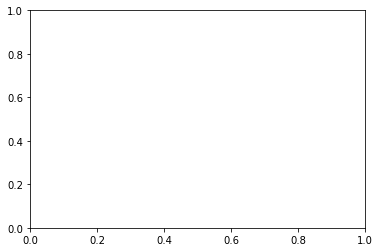

In [71]:
x=df['user'].value_counts().head()
fig,ax=plt.subplot()
ax.bar(x.index,x.values,color='red')
plt.xticks(rotation='vertical')
st.pyplot(fig)

<IPython.core.display.Javascript object>

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:>

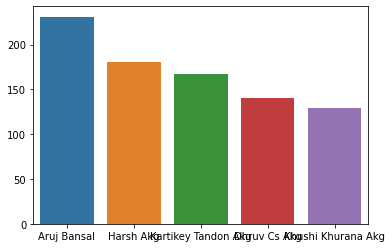

In [102]:
x=df['user'].value_counts().head()
    sns.barplot(x.index,x.values)

<IPython.core.display.Javascript object>

<BarContainer object of 5 artists>

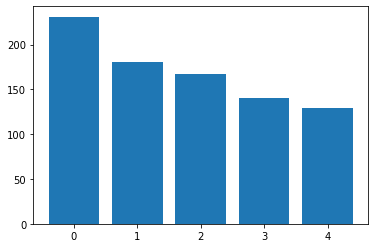

In [89]:
# ypos=np.arrange(x[0])
plt.bar([0,1,2,3,4],x['user'])

In [105]:
round(df['user'].value_counts()/df.shape[0]*100,2).reset_index().rename(columns={'index':'Name','user':'Percentage'})

,index,user
0,Aruj Bansal,9.29
1,Harsh Akg,7.24
2,Kartikey Tandon Akg,6.71
3,Dhruv Cs Akg,5.63
4,Khushi Khurana Akg,5.19
5,Gracy Gupta Akg,4.66
6,Mudit Akg,4.06
7,group_notification,3.86
8,+91 70073 61341,3.78
9,+91 86046 95404,2.98


In [106]:
from wordcloud import WordCloud

In [109]:
wc=WordCloud(width=500,height=500,min_font_size=10,background_color='white')
df_wc=wc.generate(df['message'].str.cat(sep=' '))
df_wc

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

AttributeError: module 'matplotlib.pyplot' has no attribute 'pyplot'

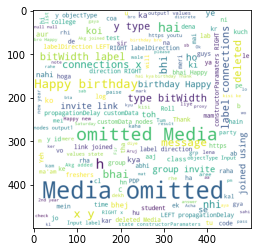

In [112]:
fig,ax=plt.subplots()
ax.imshow(df_wc)
plt.pyplot(fig)

In [139]:
df_new=df[df['message']!='<Media omitted>\n']['message']
dfc=[]
for i in df_new:
    if(i.find('joined using this group')==-1):
        dfc.append(i)
dfc = pd.Series(dfc)

In [141]:
wc=WordCloud(width=500,height=500,min_font_size=10,background_color='white')
df_wc=wc.generate(dfc.str.cat(sep=' '))
df_wc

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

AttributeError: module 'matplotlib.pyplot' has no attribute 'pyplot'

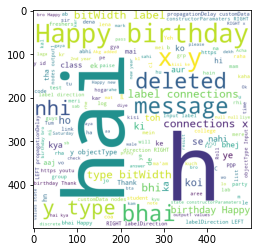

In [142]:
fig,ax=plt.subplots()
ax.imshow(df_wc)
plt.pyplot(fig)

In [144]:
from collections import Counter

In [145]:
f=open('stop_hinglish.txt','r')
stop_word=f.read()
temp=df[df['user']!='group_notification']
temp=temp[temp['message']!='<Media omitted>\n']

words=[]

for message in temp['message']:
    for word in message.lower().split():
        if word not in stop_word:
            words.append(word)
dfv=pd.DataFrame(Counter(words).most_common(20))    
dfv

,0,1
0,happy,174
1,birthday,140
2,deleted,98
3,message,97
4,😂,43
5,bhej,36
6,+1,33
7,class,31
8,dena,28
9,null,26


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='0', ylabel='1'>

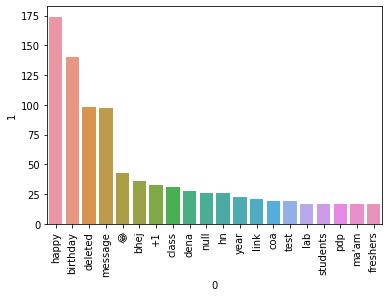

In [150]:
plt.xticks(rotation='vertical')
sns.barplot(dfv[0],dfv[1])

In [151]:
import emoji

In [154]:
emojis=[]
for message in df['message']:
    emojis.extend([c for c in message if c in emoji.EMOJI_DATA])

In [156]:
pd.DataFrame(Counter(emojis).most_common(len(Counter(emojis))))

,0,1
0,😂,146
1,🥳,88
2,🎉,85
3,🎂,81
4,🙏,29
5,❤,29
6,✨,23
7,🥹,19
8,🎊,18
9,🏻,15


In [157]:
df['month_num']=df['date'].dt.month
df

,date,user,message,year,month,day,hour,minute,month_num
0,2022-07-09 10:02:00,group_notification,Messages and calls are end-to-end encrypted. N...,2022,July,9,10,2,7
1,2022-07-09 10:00:00,group_notification,"Arun Akg created group ""CS-1 unofficial ""\n",2022,July,9,10,0,7
2,2022-07-09 10:02:00,group_notification,Archas Akg added you\n,2022,July,9,10,2,7
3,2022-07-09 10:02:00,group_notification,Deepak Khandelwal Akg added +91 70681 17946\n,2022,July,9,10,2,7
4,2022-07-09 10:02:00,group_notification,Deepak Khandelwal Akg added +91 81268 10072\n,2022,July,9,10,2,7
5,2022-07-09 10:02:00,group_notification,Alan Akg added +91 70786 55644\n,2022,July,9,10,2,7
6,2022-07-09 10:02:00,Himanshi Cs Akg,Ek link Bana ke send krdo...sb khud add ho jae...,2022,July,9,10,2,7
7,2022-07-09 10:03:00,Himanshi Cs Akg,Or vo circulate krdo\n,2022,July,9,10,3,7
8,2022-07-09 10:03:00,group_notification,+91 73557 10090 joined using this group's invi...,2022,July,9,10,3,7
9,2022-07-09 10:03:00,group_notification,+91 6388 087 440 joined using this group's inv...,2022,July,9,10,3,7


In [161]:
timeline=df.groupby(['year','month_num','month']).count()['message'].reset_index()
timeline

,year,month_num,month,message
0,2022,1,January,26
1,2022,2,February,9
2,2022,3,March,41
3,2022,4,April,36
4,2022,5,May,298
5,2022,6,June,57
6,2022,7,July,155
7,2022,8,August,100
8,2022,9,September,431
9,2022,10,October,297


In [166]:
df['only_date']=df['date'].dt.date
daily_timeline=df.groupby('only_date').count()['message'].reset_index()
daily_timeline

,only_date,message
0,2022-01-11,3
1,2022-01-12,23
2,2022-02-10,3
3,2022-02-11,5
4,2022-02-12,1
5,2022-03-10,14
6,2022-03-11,16
7,2022-03-12,11
8,2022-04-11,1
9,2022-04-12,35
